# Reto 2 · Fenotipos multidominio descubiertos en POSTCOVID-Lleida (3, 6 y 12 meses)

**Notebook 04.** Clustering de fenotipos **multidominio en POSTCOVID-Lleida**, la cohorte con el seguimiento más rico, y comparación con TENACITY y CIBERESUCICOVID. Sigue el **mismo procedimiento que el notebook 03** (que descubre en CIBERESUCICOVID), para que los dos resultados sean comparables.

| | |
|---|---|
| Definición | **Función pulmonar** (DLCO, FVC), **esfuerzo** (PM6M), **disnea** (mMRC) y **ánimo** (HADS-A, HADS-D), con peso igual por dominio. Son las variables que Lleida y TENACITY recogen de forma comparable |
| Horizontes (acumulados) | H3 = visita 1 (~3,5 meses); H6 = + visita 2 (~7 meses); H12 = + visita anual. Cada horizonte suma el cambio de cada variable entre la primera y la última medida |
| Inclusión | Superviviente, sin inconsistencias y, en la última visita, **función y (HADS o mMRC)** |
| Descripción (no define) | Astenia, fatiga muscular, FEV1, fibrosis en el TAC (formularios completos), edad, sexo, gravedad y comorbilidad |
| Comparación | **TENACITY comparte las seis variables**: replicación completa. **CIBERESUCICOVID solo comparte DLCO y FVC**: se transfiere la parte respiratoria y los fenotipos se describen con sus síntomas, reingresos y TAC |
| Pacientes compartidos | Los 437 pacientes fusionados con CIBERESUCICOVID cuentan **solo en Lleida** (`cohorte_analisis`), así que no contaminan la comparación con CIBERESUCICOVID |

**Método** (el mismo que en el notebook 03; código en `src/fenotipado_perfil.py`, configuración en `config.yaml → fenotipado_lleida`):
- Distancia de Gower: numéricas normalizadas por un rango fijo (P2,5–P97,5, idéntico en todas las cohortes), sin imputar.
- PAM, con k elegido frente a una prueba nula de permutación.
- Estabilidad bootstrap.
- Replicación: transferencia al medoide frente a clustering nativo, con emparejamiento húngaro.

> **Privacidad.** Solo agregados; celdas < 10 suprimidas. Etiquetas por paciente en `Datos limpios/fenotipos_lleida.parquet`.

## 0 · Entorno y contrato

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.metrics import adjusted_rand_score

RAIZ = Path.cwd()
sys.path.insert(0, str(RAIZ))
from src import carga, fenotipado_perfil as FP, pasaporte as P, privacidad

cfg = carga.cargar_config()
PF = FP.perfil(cfg, "fenotipado_lleida")
DESC = PF["descubre"]
REPLICAS = PF["replica"]
SEMILLA = cfg["semilla"]
N_MIN = cfg["privacidad"]["n_minimo_celda"]
COLOR = cfg["colores_registro"]
ETQ = {"CIBERESUCICOVID": "CIBERESUCICOVID", "POSTCOVID_LLEIDA": "POSTCOVID-Lleida", "TENACITY": "TENACITY"}
HORIZONTES = list(PF["horizontes"])
KS = list(range(PF["k_rango"][0], PF["k_rango"][1] + 1))
DATOS = carga.RAIZ / cfg["rutas"]["procesados"]
FIG = RAIZ / cfg["rutas"]["figuras"]; FIG.mkdir(parents=True, exist_ok=True)
TAB = RAIZ / cfg["rutas"]["tablas"]; TAB.mkdir(parents=True, exist_ok=True)
PFX = "04_lleida"

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 100, "axes.titleweight": "bold", "axes.titlesize": 11.5,
                     "axes.spines.top": False, "axes.spines.right": False})
pd.set_option("display.max_columns", 60); pd.set_option("display.width", 220)


def nota(fig, texto: str) -> None:
    fig.text(0.01, -0.01, texto, fontsize=8.5, color="0.35", va="top", ha="left")


def guardar(fig, nombre: str) -> None:
    fig.savefig(FIG / f"{PFX}_{nombre}.png", bbox_inches="tight", dpi=150)


def ic_wilson(k: int, n: int, z: float = 1.96) -> tuple[float, float]:
    if n == 0:
        return (np.nan, np.nan)
    p = k / n
    c = (p + z**2 / (2 * n)) / (1 + z**2 / n)
    m = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / (1 + z**2 / n)
    return (100 * (c - m), 100 * (c + m))


def nombre_f(c: int) -> str:
    return f"F{c + 1}"


def pct_seguro(serie: pd.Series) -> float:
    """% de 1 en una serie 0/1 (NaN si N < N_MIN o si hay entre 1 y N_MIN−1 casos)."""
    s = serie.dropna(); k = int(s.sum())
    return 100 * k / len(s) if len(s) >= N_MIN and (k == 0 or k >= N_MIN) else np.nan

In [2]:
pd.DataFrame([
    ("Descubre / replica", f"{DESC} → {', '.join(REPLICAS)}"),
    ("Visitas (tolerancia en días)", {t: d["ventana"] for t, d in PF["visitas"].items()}),
    ("Horizontes", PF["horizontes"]),
    ("Dominios de definición", PF["dominios"]),
    ("Ancla en la última visita", PF["ancla"]),
    ("Rango de normalización", PF["rango_gower"]),
    ("Elección de k", f"k en {KS}: mayor (silueta real − media nula) entre los que superan el p95 ({PF['n_permutaciones']} permutaciones)"),
    ("Estable", f"Jaccard bootstrap ({PF['n_bootstrap']}): ≥ 0,75 estable; 0,5–0,75 patrón; < 0,5 se disuelve"),
    ("Viaja", "ARI transferidas frente a nativas con IC 95 % que excluye 0; Jaccard por par ≥ 0,5"),
], columns=["criterio", "valor"]).set_index("criterio")

,valor
criterio,
Descubre / replica,"POSTCOVID_LLEIDA → TENACITY, CIBERESUCICOVID"
Visitas (tolerancia en días),"{'T3': [30, 150], 'T6': [120, 270], 'T12': [24..."
Horizontes,"{'H3': ['T3'], 'H6': ['T3', 'T6'], 'H12': ['T3..."
Dominios de definición,"{'funcion': ['dlco', 'fvc'], 'esfuerzo': ['pm6..."
Ancla en la última visita,"[[dlco, fvc], [hads_a, hads_d, mmrc]]"
Rango de normalización,"{'dlco': [40, 110], 'fvc': [55, 125], 'pm6m': ..."
Elección de k,"k en [2, 3, 4, 5, 6]: mayor (silueta real − me..."
Estable,"Jaccard bootstrap (200): ≥ 0,75 estable; 0,5–0..."
Viaja,ARI transferidas frente a nativas con IC 95 % ...


Criterios fijados **antes** de ver los resultados (`config.yaml → fenotipado_lleida`). Un fenotipo que no los cumple se presenta igualmente, como no replicado o inestable.

## 1 · Pacientes por horizonte

In [3]:
pacientes = pd.read_parquet(DATOS / "pacientes.parquet")
medidas = pd.read_parquet(DATOS / "medidas.parquet")
cohortes = [DESC, *REPLICAS]
tablas_var = {(h, c): FP.construir_variables(medidas, pacientes, cfg, PF, h, c) for h in HORIZONTES for c in cohortes}

n_tabla = pd.DataFrame({h: {ETQ[c]: len(tablas_var[(h, c)][0]) for c in cohortes} for h in HORIZONTES})
for (h, c), (t, _) in tablas_var.items():
    limite = PF["visitas"][PF["horizontes"][h][-1]]["ventana"][1]
    assert t["dias_max"].max() <= limite, "fuga de datos futuros"
print("Comprobado: ninguna variable usa datos posteriores a su horizonte.")
print("Variables por horizonte:", {h: len(tablas_var[(h, DESC)][1]) for h in HORIZONTES})
privacidad.suprimir_celdas(n_tabla, N_MIN, HORIZONTES)

Comprobado: ninguna variable usa datos posteriores a su horizonte.
Variables por horizonte: {'H3': 6, 'H6': 18, 'H12': 24}


,H3,H6,H12
POSTCOVID-Lleida,436,368,298
TENACITY,148,58,62
CIBERESUCICOVID,955,858,566


In [4]:
cobertura = pd.concat({h: tablas_var[(h, DESC)][0][tablas_var[(h, DESC)][1]].notna().mean().mul(100).round(0)
                       for h in HORIZONTES}, axis=1)
print(f"% de pacientes de {DESC} con dato en cada variable (Gower usa los pares disponibles; no se imputa):")
cobertura

% de pacientes de POSTCOVID_LLEIDA con dato en cada variable (Gower usa los pares disponibles; no se imputa):


,H3,H6,H12
dlco_T3,97.0,69.0,72.0
fvc_T3,100.0,70.0,74.0
pm6m_T3,97.0,68.0,70.0
mmrc_T3,93.0,68.0,67.0
hads_a_T3,98.0,69.0,71.0
hads_d_T3,98.0,69.0,71.0
dlco_T6,NaN,97.0,81.0
dlco_cambio,NaN,68.0,92.0
fvc_T6,NaN,99.0,83.0
fvc_cambio,NaN,70.0,95.0


## 2 · Los tres clusterings

In [5]:
def ejecutar(h: str, k_forzado: int | None = None, columnas: list[str] | None = None, filtro=None,
             n_perm: int | None = None, n_boot: int | None = None, replicar: bool = True) -> dict:
    """Clustering de un horizonte en Lleida + estabilidad + replicación en TENACITY y CIBERESUCICOVID."""
    t, cols = tablas_var[(h, DESC)]
    cols = columnas or cols
    if filtro is not None:
        t = t[filtro(t)]
    t = t[t[cols].notna().any(axis=1)]
    X = t[cols].to_numpy(float)
    R, w, cat = FP.parametros_gower(cols, PF)
    D = FP.gower(X, None, R, w, cat)
    nulo = FP.seleccion_k_nulo(X, R, w, cat, KS, n_perm or PF["n_permutaciones"], SEMILLA, D)
    k, estructura = (k_forzado, bool(nulo.set_index("k").loc[k_forzado, "supera_p95"])) if k_forzado else FP.elegir_k(nulo)
    lab, med = FP.pam(D, k, SEMILLA)
    ultima = PF["horizontes"][h][-1]
    ref = t[f"dlco_{ultima}"] if f"dlco_{ultima}" in t else t[[c for c in t.columns if c.startswith("dlco_T")]].mean(axis=1)
    lab, med = FP.ordenar_por_dlco(lab, med, ref.to_numpy(float))
    r = {"h": h, "cols": cols, "R": R, "w": w, "cat": cat, "desc": t, "X": X, "D": D, "nulo": nulo, "k": k,
         "estructura": estructura, "lab": lab, "med": med, "silueta": FP.silueta(D, lab),
         "estab": FP.estabilidad_bootstrap(D, lab, k, n_boot or PF["n_bootstrap"], SEMILLA),
         "techo": {}, "replicas": {}}
    for rep in REPLICAS:
        # ¿Se reconocen los fenotipos solo con lo que la réplica comparte? (reasignar ocultando el resto)
        comp = FP.compartidas(cfg, PF, cols, rep)
        Xc = np.where(comp, X, np.nan)
        r["techo"][rep] = adjusted_rand_score(lab, FP.asignar_medoides(FP.gower(Xc, X[med], R, w, cat)))
        if not replicar:
            continue
        tr = tablas_var[(h, rep)][0]
        if len(tr) < 2 * k:
            continue
        out = P.replicar(X, med, tr.reindex(columns=cols).to_numpy(float), R, w, cat, k,
                         n_boot or PF["n_bootstrap"], SEMILLA)
        out["datos"] = tr
        out["dif"] = P.diferencias_perfil(t, lab, tr.reindex(columns=cols), out["transferidas"],
                                          [c for c, m in zip(cols, comp) if m], k)
        r["replicas"][rep] = out
    return r


resultados = {h: ejecutar(h) for h in HORIZONTES}
for h, r in resultados.items():
    techo = ", ".join(f"{ETQ[c]} {v:.2f}" for c, v in r["techo"].items())
    print(f"{h}: N = {len(r['desc'])}, k = {r['k']}, estructura frente al nulo = {'sí' if r['estructura'] else 'NO'}, "
          f"silueta = {r['silueta']:.2f}, techo de reconocimiento (ARI): {techo}")

H3: N = 436, k = 4, estructura frente al nulo = NO, silueta = 0.11, techo de reconocimiento (ARI): TENACITY 1.00, CIBERESUCICOVID 0.09
H6: N = 368, k = 3, estructura frente al nulo = sí, silueta = 0.17, techo de reconocimiento (ARI): TENACITY 1.00, CIBERESUCICOVID 0.05
H12: N = 298, k = 3, estructura frente al nulo = sí, silueta = 0.09, techo de reconocimiento (ARI): TENACITY 1.00, CIBERESUCICOVID 0.04


## 3 · Elección de k: silueta real frente a la nula

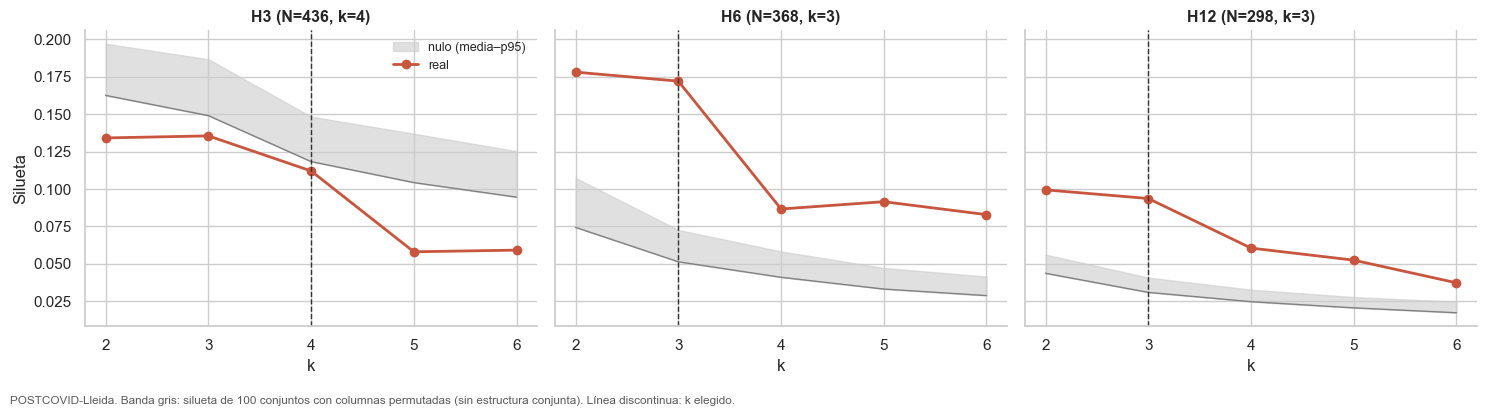

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, h in zip(axes, HORIZONTES):
    r = resultados[h]; nl = r["nulo"]
    ax.fill_between(nl["k"], nl["nulo_media"], nl["nulo_p95"], color="0.8", alpha=0.6, label="nulo (media–p95)")
    ax.plot(nl["k"], nl["nulo_media"], color="0.5", lw=1)
    ax.plot(nl["k"], nl["silueta_real"], "o-", color=COLOR[DESC], lw=2, label="real")
    ax.axvline(r["k"], color="0.2", ls="--", lw=1)
    ax.set_title(f"{h} (N={len(r['desc'])}, k={r['k']})"); ax.set_xticks(KS); ax.set_xlabel("k")
axes[0].set_ylabel("Silueta"); axes[0].legend(frameon=False, fontsize=9)
nota(fig, f"POSTCOVID-Lleida. Banda gris: silueta de {PF['n_permutaciones']} conjuntos con columnas permutadas (sin estructura conjunta). "
          "Línea discontinua: k elegido.")
plt.tight_layout(); guardar(fig, "eleccion_k"); plt.show()

## 4 · Perfiles de los fenotipos

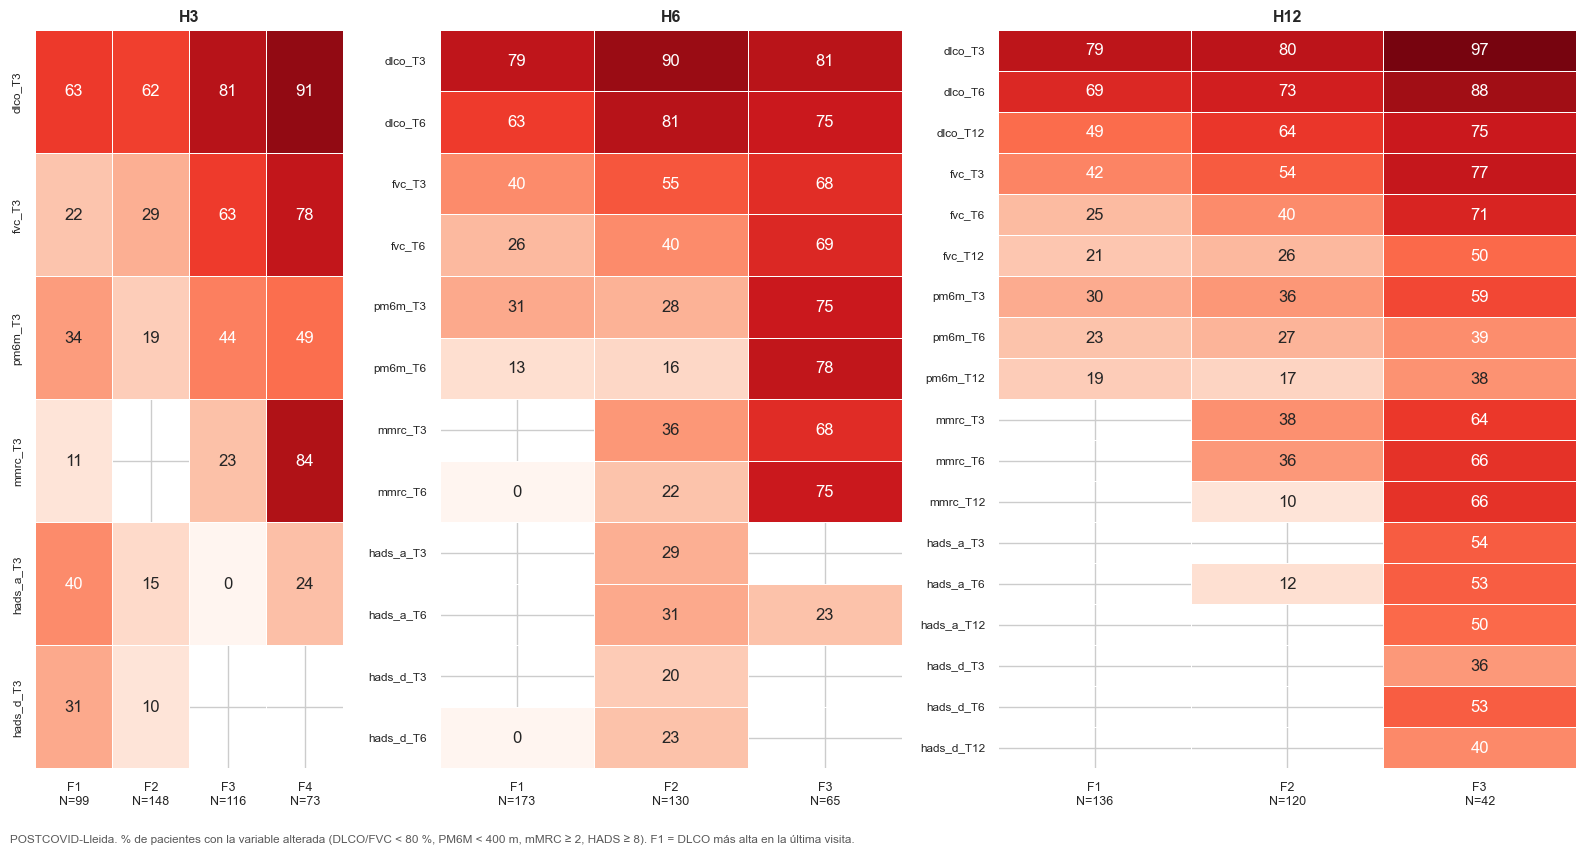

In [7]:
filas_hm = max(len([c for c in r["cols"] if not c.endswith("_cambio")]) for r in resultados.values())
fig, axes = plt.subplots(1, 3, figsize=(16, 1.5 + 0.38 * filas_hm), gridspec_kw={"width_ratios": [0.8, 1.2, 1.5]})
for ax, h in zip(axes, HORIZONTES):
    r = resultados[h]
    pct, n_alt = FP.porcentaje_alterado(r["desc"], r["cols"], r["lab"], cfg)
    tam = pd.Series(r["lab"]).value_counts().sort_index()
    oculta = (n_alt > 0) & (n_alt < N_MIN)
    oculta.loc[:, tam[tam < N_MIN].index] = True
    etiquetas = pct.round(0).astype("Int64").astype(str).mask(oculta, "<10")
    visible = pct.mask(oculta)
    visible.columns = [f"{nombre_f(c)}\nN={tam[c] if tam[c] >= N_MIN else '<10'}" for c in pct.columns]
    sns.heatmap(visible, annot=etiquetas.values, fmt="", cmap="Reds", vmin=0, vmax=100, cbar=False, ax=ax, linewidths=0.5)
    ax.set_title(h); ax.set_ylabel(""); ax.tick_params(axis="x", rotation=0, labelsize=9); ax.tick_params(axis="y", labelsize=8.5)
nota(fig, "POSTCOVID-Lleida. % de pacientes con la variable alterada (DLCO/FVC < 80 %, PM6M < 400 m, mMRC ≥ 2, HADS ≥ 8). "
          "F1 = DLCO más alta en la última visita.")
plt.tight_layout(); guardar(fig, "perfiles"); plt.show()

In [8]:
filas = []
for h, r in resultados.items():
    med_ = r["desc"][r["cols"]].groupby(r["lab"]).median()
    for c, fila in med_.iterrows():
        if (r["lab"] == c).sum() >= N_MIN:
            filas.append({"horizonte": h, "fenotipo": nombre_f(c), "N": int((r["lab"] == c).sum()), **fila.round(1).to_dict()})
medianas = pd.DataFrame(filas).set_index(["horizonte", "fenotipo"])
medianas.to_csv(TAB / f"{PFX}_medianas_fenotipos.csv")
print("Medianas por fenotipo:")
medianas

Medianas por fenotipo:


N  dlco_T3  fvc_T3  pm6m_T3  mmrc_T3  hads_a_T3  hads_d_T3  dlco_T6  dlco_cambio  fvc_T6  fvc_cambio  pm6m_T6  pm6m_cambio  mmrc_T6  mmrc_cambio  hads_a_T6  hads_a_cambio  hads_d_T6  \
horizonte fenotipo                                                                                                                                                                                            
H3        F1         99     75.5    86.7    440.0      1.0        6.0        5.0      NaN          NaN     NaN         NaN      NaN          NaN      NaN          NaN        NaN            NaN        NaN   
          F2        148     75.0    87.0    435.0      0.0        3.0        2.0      NaN          NaN     NaN         NaN      NaN          NaN      NaN          NaN        NaN            NaN        NaN   
          F3        116     65.0    77.0    420.0      0.0        1.0        0.0      NaN          NaN     NaN         NaN      NaN          NaN      NaN          NaN        NaN            NaN        NaN   
          F4         73     59.0    68.3    400.0      2.0        4.5        3.0      NaN          NaN     NaN         NaN      NaN          NaN      NaN          NaN        NaN            NaN        NaN   
H6        F1        173     68.0    81.6    432.5      0.0        1.0        1.0     74.0          5.0    87.8         5.0    462.5         30.0      0.0          0.0        1.0            0.0        1.0   
          F2        130     64.0    77.0    440.0      1.0        4.0        2.0     67.7          3.0    85.0         5.0    450.0         20.0      1.0          0.0        4.0            0.0        3.0   
          F3         65     64.5    69.0    322.5      2.0        4.0        4.0     64.5          4.0    72.0         5.6    325.0         10.0      2.0          0.0        2.0            0.0        3.0   
H12       F1        136     70.0    81.0    440.0      0.0        1.0        1.0     72.0          7.0    87.0         7.0    450.0         20.0      0.0          0.0        1.0            0.0        1.0   
          F2        120     62.6    79.0    420.0      1.0        3.0        2.0     69.0          8.0    85.0         6.1    440.0         15.0      1.0          0.0        2.0           -1.0        1.5   
          F3         42     62.7    70.5    385.0      2.0        8.0        7.0     64.0          6.0    74.4         4.0    415.0         40.0      2.0          0.0        8.0           -1.0        8.0   

                    hads_d_cambio  dlco_T12  fvc_T12  pm6m_T12  mmrc_T12  hads_a_T12  hads_d_T12  
horizonte fenotipo                                                                                
H3        F1                  NaN       NaN      NaN       NaN       NaN         NaN         NaN  
          F2                  NaN       NaN      NaN       NaN       NaN         NaN         NaN  
          F3                  NaN       NaN      NaN       NaN       NaN         NaN         NaN  
          F4                  NaN       NaN      NaN       NaN       NaN         NaN         NaN  
H6        F1                  0.0       NaN      NaN       NaN       NaN         NaN         NaN  
          F2                  0.0       NaN      NaN       NaN       NaN         NaN         NaN  
          F3                 -1.0       NaN      NaN       NaN       NaN         NaN         NaN  
H12       F1                  0.0      80.0     92.0     460.0       0.0         1.0         1.0  
          F2                 -1.0      73.0     87.0     440.0       1.0         1.0         1.0  
          F3                  0.0      67.0     79.0     407.5       2.0         8.0         6.0

### Fichas: descripción con variables que no definen el fenotipo

Cada cohorte se describe con lo que recoge:
- **"Alguna"** (eventos, hallazgos de imagen): % que lo presenta en alguna visita hasta el horizonte; la imagen, solo entre quienes tienen TAC.
- **"Última"** (FEV1, síntomas, cuestionarios): estado en la visita más reciente con medida.
- **Variables del ingreso.**

In [9]:
VARS_DEF = set(FP.variables_definicion(PF))
IMAGEN = ("tac_", "tractos", "fibrosis")


def ficha(h: str, cohorte: str, datos: pd.DataFrame, etiquetas: np.ndarray, k: int) -> pd.DataFrame:
    visitas = PF["horizontes"][h]
    p = pacientes.set_index("subject_id").reindex(datos.index)
    seguimiento = {}
    for regla in ["alguna", "ultima"]:
        for v in PF["descripcion"][regla]:
            if v in VARS_DEF:
                continue
            if v.startswith(IMAGEN) or FP.visitas_que_recogen(cfg, PF, v, cohorte):
                seguimiento[v] = FP.estado_hasta(medidas, cfg, PF, cohorte, datos.index, v, visitas, regla)
    filas = {}
    for c in range(k):
        s = etiquetas == c
        sub = p[s]
        col = {"N": int(s.sum())}
        if s.sum() >= N_MIN:
            col["Edad ≥ 65 (%)"] = pct_seguro(sub["grupo_edad"].isin(["65-74", ">=75"]).astype(float).where(sub["grupo_edad"].notna()))
            col["Mujeres (%)"] = pct_seguro((sub["sexo"] == 1).astype(float).where(sub["sexo"].notna()))
            col["Estancia (mediana, días)"] = sub["estancia_hosp_dias"].median()
            for v in PF["descripcion"]["ingreso_binarias"]:
                col[f"{v.replace('nu_', '')} (%)"] = pct_seguro(sub[v])
            for v, serie in seguimiento.items():
                col[f"{v} (% sí / alterado)"] = pct_seguro(serie[s])
        filas[nombre_f(c)] = col
    return pd.DataFrame(filas).round(1)


fichas = {(h, DESC): ficha(h, DESC, r["desc"], r["lab"], r["k"]) for h, r in resultados.items()}
for h, r in resultados.items():
    print(f"\n=== {h} · {DESC} ===")
    display(fichas[(h, DESC)].dropna(how="all"))


=== H3 · POSTCOVID_LLEIDA ===


,F1,F2,F3,F4
N,99.0,148.0,116.0,73.0
Edad ≥ 65 (%),24.5,38.4,37.9,33.3
Mujeres (%),46.4,29.0,14.7,38.9
"Estancia (mediana, días)",14.0,15.0,17.0,22.0
ingreso_uci (%),81.8,81.0,66.4,79.5
traqueo (%),NaN,14.9,20.0,22.8
hta (%),45.7,46.9,51.3,42.9
diabetes (%),17.0,19.7,24.3,24.3
fibrosis_estricta (% sí / alterado),NaN,17.7,25.8,39.0
fibrosis_amplia (% sí / alterado),63.3,63.3,80.6,68.3



=== H6 · POSTCOVID_LLEIDA ===


,F1,F2,F3
N,173.0,130.0,65.0
Edad ≥ 65 (%),42.4,34.1,44.4
Mujeres (%),20.0,39.8,34.9
"Estancia (mediana, días)",16.0,18.0,20.0
ingreso_uci (%),72.8,78.5,70.8
traqueo (%),19.5,14.1,47.6
hta (%),45.0,43.7,70.0
diabetes (%),18.3,23.2,31.7
card_cronica (%),NaN,NaN,16.7
fibrosis_estricta (% sí / alterado),29.1,41.1,37.9



=== H12 · POSTCOVID_LLEIDA ===


,F1,F2,F3
N,136.0,120.0,42.0
Edad ≥ 65 (%),48.9,47.9,NaN
Mujeres (%),20.0,31.1,40.0
"Estancia (mediana, días)",19.0,18.0,23.0
ingreso_uci (%),77.9,77.5,78.6
traqueo (%),18.4,25.8,NaN
hta (%),53.8,53.4,41.5
diabetes (%),19.7,31.0,NaN
card_cronica (%),7.6,NaN,NaN
fibrosis_estricta (% sí / alterado),40.7,43.1,NaN


## 5 · Estabilidad

In [10]:
filas = []
for h, r in resultados.items():
    for _, e in r["estab"].iterrows():
        filas.append({"horizonte": h, "fenotipo": nombre_f(int(e["cluster"])), "N": int(e["n"]),
                      "Jaccard medio": round(e["jaccard_medio"], 2), "Jaccard p05": round(e["jaccard_p05"], 2)})
estab = pd.DataFrame(filas)
estab["veredicto"] = pd.cut(estab["Jaccard medio"], [0, 0.5, 0.75, 1.01], labels=["se disuelve", "patrón", "estable"])
estab.to_csv(TAB / f"{PFX}_estabilidad.csv", index=False)
print("Estabilidad entre centros: no aplica (POSTCOVID-Lleida es un solo centro).")
privacidad.suprimir_celdas(estab.set_index(["horizonte", "fenotipo"]), N_MIN, ["N"])

Estabilidad entre centros: no aplica (POSTCOVID-Lleida es un solo centro).


N  Jaccard medio  Jaccard p05 veredicto
horizonte fenotipo                                           
H3        F1         99           0.64         0.30    patrón
          F2        148           0.69         0.37    patrón
          F3        116           0.52         0.21    patrón
          F4         73           0.58         0.22    patrón
H6        F1        173           0.78         0.43   estable
          F2        130           0.58         0.29    patrón
          F3         65           0.55         0.26    patrón
H12       F1        136           0.72         0.46    patrón
          F2        120           0.65         0.28    patrón
          F3         42           0.54         0.13    patrón

## 6 · Comparación con TENACITY y CIBERESUCICOVID

### 6.1 ¿Se reconocen los fenotipos con lo que comparte cada cohorte?

En Lleida, cada paciente se reasigna a su medoide **ocultando las variables que la otra cohorte no recoge**. Ese ARI es el **techo** de lo que la transferencia puede reproducir:
- TENACITY lo comparte todo: techo 1.
- CIBERESUCICOVID solo comparte DLCO y FVC: su techo dice cuánto del fenotipo multidominio es reconocible con la función pulmonar.

In [11]:
pd.DataFrame({h: {f"techo {ETQ[c]}": round(v, 2) for c, v in r["techo"].items()} for h, r in resultados.items()}).T

,techo TENACITY,techo CIBERESUCICOVID
H3,1.0,0.09
H6,1.0,0.05
H12,1.0,0.04


### 6.2 Replicación: transferidas frente a nativas

In [12]:
filas = []
for h, r in resultados.items():
    for rep, out in r["replicas"].items():
        fila = {"horizonte": h, "replica en": ETQ[rep], "N": out["n"], "k": r["k"], "techo": round(r["techo"][rep], 2),
                "ARI": round(out["ari"], 2), "ARI IC95": f"{out['ari_ic'][0]:.2f} a {out['ari_ic'][1]:.2f}"}
        for c in range(r["k"]):
            fila[f"Jaccard {nombre_f(c)}"] = f"{out['jaccard'][c]:.2f} ({out['jaccard_ic'][c][0]:.2f}–{out['jaccard_ic'][c][1]:.2f})"
        dif = out["dif"].abs()
        fila["% perfiles con |d| < 0,5"] = round(100 * (dif < 0.5).sum().sum() / max(dif.notna().sum().sum(), 1))
        filas.append(fila)
replicacion = pd.DataFrame(filas).set_index(["horizonte", "replica en"])
replicacion.to_csv(TAB / f"{PFX}_replicacion.csv")
replicacion

N  k  techo   ARI     ARI IC95        Jaccard F1        Jaccard F2        Jaccard F3        Jaccard F4  % perfiles con |d| < 0,5
horizonte replica en                                                                                                                                         
H3        TENACITY         148  4   1.00  0.17  0.14 a 0.33  0.38 (0.20–0.57)  0.39 (0.33–0.62)  0.16 (0.09–0.40)  0.28 (0.00–0.38)                        92
          CIBERESUCICOVID  955  4   0.09  0.34  0.23 a 0.39  0.39 (0.20–0.41)  0.38 (0.23–0.47)  0.60 (0.22–0.66)  0.58 (0.48–0.85)                        62
H6        TENACITY          58  3   1.00  0.31  0.07 a 0.58  0.67 (0.33–0.85)  0.23 (0.07–0.53)  0.48 (0.17–0.58)               NaN                        80
          CIBERESUCICOVID  858  3   0.05  0.18  0.14 a 0.40  0.53 (0.41–0.68)  0.21 (0.14–0.36)  0.43 (0.36–0.84)               NaN                        78
H12       TENACITY          62  3   1.00  0.15  0.02 a 0.59  0.54 (0.35–0.83)  0.23 (0.11–0.60)  0.40 (0.19–0.73)               NaN                        81
          CIBERESUCICOVID  566  3   0.04  0.06  0.03 a 0.18  0.22 (0.11–0.27)  0.29 (0.27–0.52)  0.33 (0.15–0.55)               NaN                        67

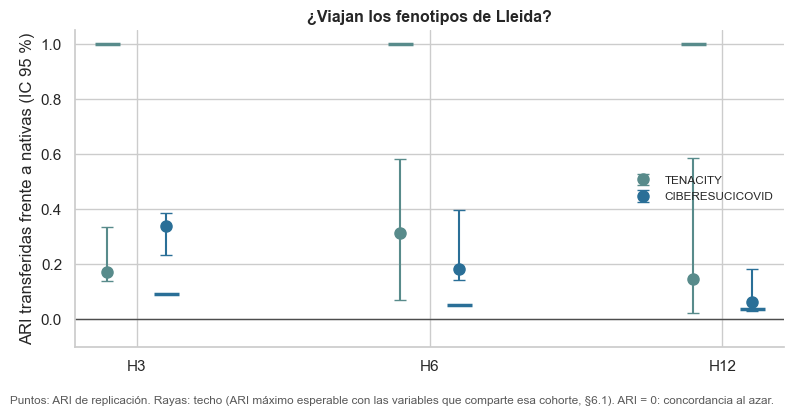

In [13]:
fig, ax = plt.subplots(figsize=(8, 4))
for i, rep in enumerate(REPLICAS):
    xs, ys, lo, hi, tx = [], [], [], [], []
    for j, h in enumerate(HORIZONTES):
        out = resultados[h]["replicas"].get(rep)
        if out is None:
            continue
        x = j + (i - (len(REPLICAS) - 1) / 2) * 0.2
        xs.append(x); ys.append(out["ari"]); tx.append(resultados[h]["techo"][rep])
        lo.append(out["ari"] - out["ari_ic"][0]); hi.append(out["ari_ic"][1] - out["ari"])
    ax.errorbar(xs, ys, yerr=[lo, hi], fmt="o", ms=8, capsize=4, color=COLOR[rep], label=ETQ[rep])
    ax.plot(xs, tx, "_", color=COLOR[rep], ms=18, mew=2.5)
ax.axhline(0, color="0.3", lw=1); ax.set_xticks(range(len(HORIZONTES)), HORIZONTES); ax.set_ylim(-0.1, 1.05)
ax.set_ylabel("ARI transferidas frente a nativas (IC 95 %)"); ax.set_title("¿Viajan los fenotipos de Lleida?")
ax.legend(frameon=False, fontsize=8.5)
nota(fig, "Puntos: ARI de replicación. Rayas: techo (ARI máximo esperable con las variables que comparte esa cohorte, §6.1). "
          "ARI = 0: concordancia al azar.")
plt.tight_layout(); guardar(fig, "replicacion_ari"); plt.show()

### 6.3 Los fenotipos de Lleida descritos en las otras cohortes

Los pacientes de TENACITY y CIBERESUCICOVID se asignan al fenotipo más cercano, con lo que comparten, y se describen con todo lo que cada cohorte recoge. En CIBERESUCICOVID eso incluye fatiga, resolución clínica, reingresos, urgencias y hallazgos del TAC.

In [14]:
for h, r in resultados.items():
    bloques = {ETQ[DESC]: fichas[(h, DESC)]}
    for rep, out in r["replicas"].items():
        fichas[(h, rep)] = ficha(h, rep, out["datos"], out["transferidas"], r["k"])
        bloques[ETQ[rep]] = fichas[(h, rep)]
    print(f"\n=== {h} ===")
    display(pd.concat(bloques, axis=1).dropna(how="all"))
pd.concat({f"{h}|{c}": f for (h, c), f in fichas.items()}, names=["horizonte|cohorte", "variable"]).to_csv(TAB / f"{PFX}_fichas.csv")


=== H3 ===


POSTCOVID-Lleida                     TENACITY                      CIBERESUCICOVID                     
                                                     F1     F2     F3    F4       F1     F2     F3     F4              F1     F2     F3     F4
N                                                  99.0  148.0  116.0  73.0     37.0   61.0   37.0   13.0           257.0  319.0  196.0  183.0
Edad ≥ 65 (%)                                      24.5   38.4   37.9  33.3     36.4   35.8   48.4    NaN            35.0   30.1   25.5   31.7
Mujeres (%)                                        46.4   29.0   14.7  38.9     54.8   40.4    NaN    NaN            30.4   30.5   22.4   27.3
Estancia (mediana, días)                           14.0   15.0   17.0  22.0     21.0   15.0   24.0   17.0            25.0   23.0   30.0   37.0
ingreso_uci (%)                                    81.8   81.0   66.4  79.5    100.0  100.0  100.0  100.0           100.0  100.0  100.0  100.0
traqueo (%)                                         NaN   14.9   20.0  22.8      NaN    NaN    NaN    NaN            26.1   22.6   37.8   45.4
hta (%)                                            45.7   46.9   51.3  42.9     45.9   31.1   64.9    NaN            44.0   38.2   44.9   49.2
diabetes (%)                                       17.0   19.7   24.3  24.3      NaN   27.9   32.4    NaN            13.6   11.9   21.4   16.4
epoc (%)                                            NaN    NaN    NaN   NaN      NaN    NaN    NaN    NaN             3.9    4.1    NaN    6.6
card_cronica (%)                                    NaN    NaN    NaN   NaN      NaN    NaN    NaN    NaN             9.3    9.4   10.2   13.7
renal_cronica (%)                                   NaN    NaN    NaN   NaN      NaN    NaN    NaN    NaN             NaN    NaN    6.1    8.2
tac_normalizado (% sí / alterado)                   NaN    NaN    NaN   NaN      NaN    NaN    NaN    NaN            18.3   20.8   14.9   11.6
tac_infiltrados (% sí / alterado)                   NaN    NaN    NaN   NaN      NaN    NaN    NaN    NaN            26.9   28.2   33.7   18.9
tac_epid (% sí / alterado)                          NaN    NaN    NaN   NaN      NaN    NaN    NaN    NaN            10.8    NaN    NaN   14.7
tractos_fibrosos (% sí / alterado)                  NaN    NaN    NaN   NaN      NaN    NaN    NaN    NaN            19.4   14.8   25.7   34.7
fibrosis_estricta (% sí / alterado)                 NaN   17.7   25.8  39.0      NaN    NaN    NaN    NaN             NaN    NaN    NaN    NaN
fibrosis_amplia (% sí / alterado)                  63.3   63.3   80.6  68.3      NaN    NaN    NaN    NaN             NaN    NaN    NaN    NaN
fev1 (% sí / alterado)                             13.1   17.7   44.7  67.1     32.4   24.6   75.7   92.3             4.0    5.7   34.4   92.0
astenia (% sí / alterado)                           NaN    NaN    NaN   NaN     33.3    NaN    NaN    NaN             NaN    NaN    NaN    NaN
fatiga_muscular (% sí / alterado)                  28.4   21.4   13.5  30.2      NaN    NaN    NaN    NaN             NaN    NaN    NaN    NaN
reingreso (% sí / alterado)                         NaN    NaN    NaN   NaN      NaN    NaN    NaN    NaN             4.7    NaN    NaN    6.1
urgencias (% sí / alterado)                         NaN    NaN    NaN   NaN      NaN    NaN    NaN    NaN            17.2   14.3   14.1   18.2
compl_cardiovascular (% sí / alterado)              NaN    NaN    NaN   NaN      NaN    NaN    NaN    NaN             NaN    3.5    NaN    NaN
compl_infecciosa (% sí / alterado)                  NaN    NaN    NaN   NaN      NaN    NaN    NaN    NaN             NaN    4.1    NaN    NaN
fatiga (% sí / alterado)                            NaN    NaN    NaN   NaN      NaN    NaN    NaN    NaN            38.3   35.9   41.8   45.4
resolucion (% sí / alterado)                        NaN    NaN    NaN   NaN      NaN    NaN    NaN    NaN            69.7   63.7   74.1   86.2


=== H6 ===


POSTCOVID-Lleida              TENACITY               CIBERESUCICOVID              
                                                     F1     F2    F3       F1     F2     F3              F1     F2     F3
N                                                 173.0  130.0  65.0     29.0   14.0   15.0           446.0  174.0  238.0
Edad ≥ 65 (%)                                      42.4   34.1  44.4     48.0    NaN    NaN            33.4   43.7   33.2
Mujeres (%)                                        20.0   39.8  34.9      NaN    NaN    NaN            28.5   42.0   21.0
Estancia (mediana, días)                           16.0   18.0  20.0     24.0   22.0   17.0            26.0   32.0   37.0
ingreso_uci (%)                                    72.8   78.5  70.8    100.0  100.0  100.0           100.0  100.0  100.0
traqueo (%)                                        19.5   14.1  47.6      NaN    NaN    NaN            27.6   39.7   44.1
hta (%)                                            45.0   43.7  70.0     37.9    NaN    NaN            42.2   48.3   46.2
diabetes (%)                                       18.3   23.2  31.7      NaN    NaN    NaN            18.6   21.3   21.8
epoc (%)                                            NaN    NaN   NaN      NaN    NaN    NaN             4.9    NaN    4.2
card_cronica (%)                                    NaN    NaN  16.7      NaN    NaN    NaN             8.3   13.8   13.4
renal_cronica (%)                                   NaN    NaN   NaN      NaN    0.0    NaN             3.4    5.7    6.3
tac_normalizado (% sí / alterado)                   NaN    NaN   NaN      NaN    NaN    NaN            21.6   15.9   19.9
tac_infiltrados (% sí / alterado)                   NaN    NaN   NaN      NaN    NaN    NaN            34.8   34.1   29.2
tac_epid (% sí / alterado)                          NaN    NaN   NaN      NaN    NaN    NaN             6.8    NaN    9.3
tractos_fibrosos (% sí / alterado)                  NaN    NaN   NaN      NaN    NaN    NaN            22.3   33.3   29.8
fibrosis_estricta (% sí / alterado)                29.1   41.1  37.9      NaN    NaN    NaN             NaN    NaN    NaN
fibrosis_amplia (% sí / alterado)                  77.9   75.0  89.7      NaN    NaN    NaN             NaN    NaN    NaN
fev1 (% sí / alterado)                             17.3   21.5  56.9      NaN    NaN    NaN             3.8    7.3   55.0
fatiga_muscular (% sí / alterado)                   7.7   29.5  39.7      NaN    NaN    NaN             NaN    NaN    NaN
reingreso (% sí / alterado)                         NaN    NaN   NaN      NaN    NaN    NaN             5.4    7.5    9.4
urgencias (% sí / alterado)                         NaN    NaN   NaN      NaN    NaN    NaN            22.6   27.6   26.0
compl_cardiovascular (% sí / alterado)              NaN    NaN   NaN      NaN    NaN    NaN             4.5    NaN    6.0
compl_infecciosa (% sí / alterado)                  NaN    NaN   NaN      NaN    NaN    NaN             5.0    6.9    8.1
fatiga (% sí / alterado)                            NaN    NaN   NaN      NaN    NaN    NaN            35.0   33.3   40.7
resolucion (% sí / alterado)                        NaN    NaN   NaN      NaN    NaN    NaN            62.0   60.8   79.0


=== H12 ===


POSTCOVID-Lleida              TENACITY               CIBERESUCICOVID              
                                                  F1     F2    F3       F1     F2     F3              F1     F2     F3
N                                              136.0  120.0  42.0     35.0   12.0   15.0           175.0  288.0  103.0
Edad ≥ 65 (%)                                   48.9   47.9   NaN     37.5    NaN    NaN            32.0   42.4   38.8
Mujeres (%)                                     20.0   31.1  40.0      NaN    NaN    NaN            25.1   31.9   23.3
Estancia (mediana, días)                        19.0   18.0  23.0     19.0   14.0   37.0            27.0   30.0   44.0
ingreso_uci (%)                                 77.9   77.5  78.6    100.0  100.0  100.0           100.0   99.7  100.0
traqueo (%)                                     18.4   25.8   NaN      NaN    NaN    NaN            29.9   31.6   54.9
hta (%)                                         53.8   53.4  41.5     40.0    NaN    NaN            48.0   43.8   54.4
diabetes (%)                                    19.7   31.0   NaN      NaN    NaN    NaN            20.0   17.0   22.3
epoc (%)                                         NaN    NaN   NaN      NaN    NaN    NaN             NaN    5.9    NaN
card_cronica (%)                                 7.6    NaN   NaN      NaN    NaN    NaN             9.1    9.0   17.5
renal_cronica (%)                                NaN    NaN   NaN      NaN    NaN    NaN             NaN    4.9   11.7
tac_normalizado (% sí / alterado)                NaN    NaN   NaN      NaN    NaN    NaN            28.1   25.3    NaN
tac_infiltrados (% sí / alterado)                NaN    NaN   NaN      NaN    NaN    NaN            40.6   42.6   36.6
tac_epid (% sí / alterado)                       NaN    NaN   NaN      NaN    NaN    NaN            10.2    7.9    NaN
tractos_fibrosos (% sí / alterado)               NaN    NaN   NaN      NaN    NaN    NaN            35.9   30.5   43.9
fibrosis_estricta (% sí / alterado)             40.7   43.1   NaN      NaN    NaN    NaN             NaN    NaN    NaN
fibrosis_amplia (% sí / alterado)               92.6   86.3  80.0      NaN    NaN    NaN             NaN    NaN    NaN
fev1 (% sí / alterado)                          20.6   19.2  47.6     37.1    NaN   73.3            13.4    7.4   64.1
astenia (% sí / alterado)                        NaN    NaN   NaN      NaN    0.0    NaN             NaN    NaN    NaN
fatiga_muscular (% sí / alterado)               11.1   19.0  56.1      NaN    NaN    NaN             NaN    NaN    NaN
reingreso (% sí / alterado)                      NaN    NaN   NaN      NaN    NaN    NaN             9.7    8.7   16.5
urgencias (% sí / alterado)                      NaN    NaN   NaN      NaN    NaN    NaN            29.7   25.4   45.6
compl_infecciosa (% sí / alterado)               NaN    NaN   NaN      NaN    NaN    NaN             8.2    3.9    9.9
fatiga (% sí / alterado)                         NaN    NaN   NaN      NaN    NaN    NaN            36.7   36.6   36.5
resolucion (% sí / alterado)                     NaN    NaN   NaN      NaN    NaN    NaN            66.3   62.9   82.5

## 7 · Comparación entre horizontes

### 7.1 Pasaporte conjunto

In [15]:
pasaporte = pd.DataFrame([{
    "horizonte": h, "N": len(r["desc"]), "k": r["k"], "estructura": "sí" if r["estructura"] else "no",
    "silueta − nula": round(r["silueta"] - r["nulo"].set_index("k").loc[r["k"], "nulo_media"], 3),
    "Jaccard estabilidad (mín)": round(r["estab"]["jaccard_medio"].min(), 2),
    **{f"techo {ETQ[c]}": round(v, 2) for c, v in r["techo"].items()},
    **{f"ARI {ETQ[rep]}": f"{o['ari']:.2f} [{o['ari_ic'][0]:.2f}, {o['ari_ic'][1]:.2f}]" for rep, o in r["replicas"].items()},
} for h, r in resultados.items()]).set_index("horizonte")
pasaporte.to_csv(TAB / f"{PFX}_pasaporte.csv")
pasaporte

,N,k,estructura,silueta − nula,Jaccard estabilidad (mín),techo TENACITY,techo CIBERESUCICOVID,ARI TENACITY,ARI CIBERESUCICOVID
horizonte,,,,,,,,,
H3,436,4,no,-0.006,0.52,1.0,0.09,"0.17 [0.14, 0.33]","0.34 [0.23, 0.39]"
H6,368,3,sí,0.121,0.55,1.0,0.05,"0.31 [0.07, 0.58]","0.18 [0.14, 0.40]"
H12,298,3,sí,0.063,0.54,1.0,0.04,"0.15 [0.02, 0.59]","0.06 [0.03, 0.18]"


### 7.2 Transiciones entre horizontes

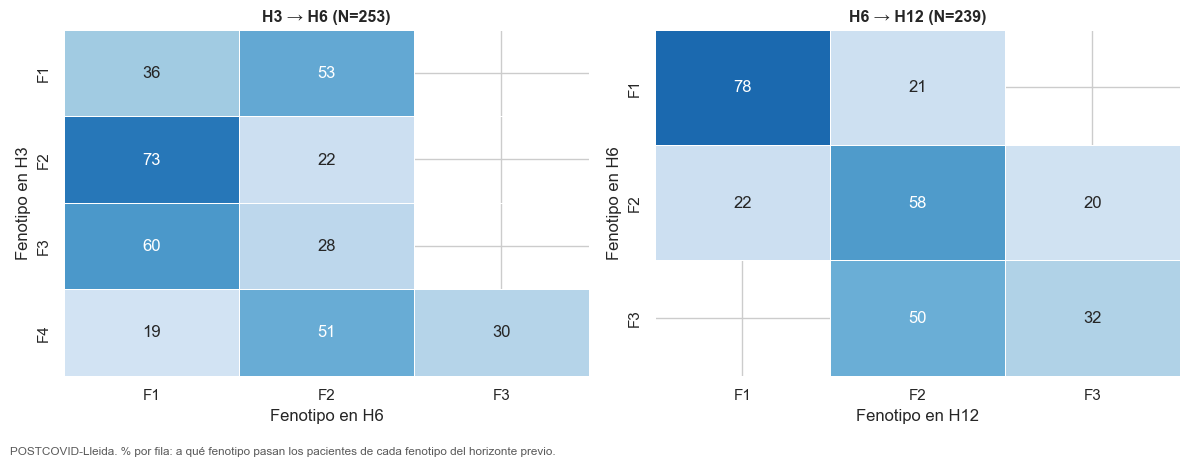

,pacientes comunes,ARI
transición,,
H3 → H6,253,0.08
H6 → H12,239,0.22


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
filas = []
for ax, (h1, h2) in zip(axes, [("H3", "H6"), ("H6", "H12")]):
    r1, r2 = resultados[h1], resultados[h2]
    e1 = pd.Series([nombre_f(c) for c in r1["lab"]], index=r1["desc"].index)
    e2 = pd.Series([nombre_f(c) for c in r2["lab"]], index=r2["desc"].index)
    tabla, ari, n = P.transiciones(e1, e2)
    filas.append({"transición": f"{h1} → {h2}", "pacientes comunes": n, "ARI": round(ari, 2)})
    if n:
        pct = tabla.div(tabla.sum(axis=1), axis=0) * 100
        anot = pct.round(0).astype(int).astype(str).mask(tabla < N_MIN, "<10")
        sns.heatmap(pct.mask(tabla < N_MIN), annot=anot.values, fmt="", cmap="Blues", vmin=0, vmax=100, cbar=False, ax=ax, linewidths=0.5)
    ax.set_xlabel(f"Fenotipo en {h2}"); ax.set_ylabel(f"Fenotipo en {h1}"); ax.set_title(f"{h1} → {h2} (N={n})")
nota(fig, "POSTCOVID-Lleida. % por fila: a qué fenotipo pasan los pacientes de cada fenotipo del horizonte previo.")
plt.tight_layout(); guardar(fig, "transiciones"); plt.show()
pd.DataFrame(filas).set_index("transición")

### 7.3 ¿El fenotipo a 3 meses anticipa el año?

Para los pacientes fenotipados en H3 se calcula el % con cada desenlace a 12 meses (DLCO < 80 %, HADS-A ≥ 8, mMRC ≥ 2) según su fenotipo, en cada cohorte que recoge ese desenlace. En TENACITY y CIBERESUCICOVID se usan las etiquetas transferidas.

In [17]:
r = resultados["H3"]
grupos = {DESC: (r["desc"], r["lab"])}
grupos.update({rep: (o["datos"], o["transferidas"]) for rep, o in r["replicas"].items()})
filas, pruebas = [], []
for coh, (datos, lab) in grupos.items():
    for nombre, v, visitas, regla in PF["desenlaces"]:
        if not FP.visitas_que_recogen(cfg, PF, v, coh) & set(visitas):
            continue
        y = FP.estado_hasta(medidas, cfg, PF, coh, datos.index, v, visitas, regla)
        ok = y.notna().values
        if ok.sum() < N_MIN:
            continue
        ct = pd.crosstab(lab[ok], y.values[ok])
        if ct.shape[1] == 2 and (ct.values > 0).all():
            pruebas.append({"cohorte": ETQ[coh], "desenlace": nombre, "N": int(ok.sum()),
                            "p (χ²)": f"{stats.chi2_contingency(ct)[1]:.2g}"})
        for c in range(r["k"]):
            s = y.values[ok & (lab == c)]
            k = int(np.nansum(s))
            if len(s) < N_MIN or 0 < k < N_MIN:
                continue
            lo, hi = ic_wilson(k, len(s))
            filas.append({"cohorte": ETQ[coh], "desenlace": nombre, "fenotipo H3": nombre_f(c), "N": len(s),
                          "%": round(100 * k / len(s), 1), "IC95": f"{lo:.0f}–{hi:.0f}"})
pronostico = pd.DataFrame(filas)
pronostico.to_csv(TAB / f"{PFX}_pronostico_h3.csv", index=False)
display(pd.DataFrame(pruebas).set_index(["cohorte", "desenlace"]) if pruebas else "sin pruebas evaluables")
pronostico.set_index(["cohorte", "desenlace", "fenotipo H3"]) if len(pronostico) else "sin desenlaces evaluables"

N   p (χ²)
cohorte          desenlace                       
POSTCOVID-Lleida DLCO < 80 % a 12 m  208  0.00031
                 HADS-A ≥ 8 a 12 m   258  0.00083
                 mMRC ≥ 2 a 12 m     252   0.0027
TENACITY         DLCO < 80 % a 12 m   49    0.035
                 mMRC ≥ 2 a 12 m      88     0.19
CIBERESUCICOVID  DLCO < 80 % a 12 m  226   0.0047

N     %   IC95
cohorte          desenlace          fenotipo H3                 
POSTCOVID-Lleida DLCO < 80 % a 12 m F1           51  35.3  24–49
                                    F2           57  52.6  40–65
                                    F3           57  59.6  47–71
                                    F4           43  79.1  65–89
                 HADS-A ≥ 8 a 12 m  F1           66  25.8  17–37
                                    F2           79  12.7   7–22
                 mMRC ≥ 2 a 12 m    F3           65  15.4   9–26
                                    F4           46  26.1  16–40
CIBERESUCICOVID  DLCO < 80 % a 12 m F1           59  57.6  45–69
                                    F2           64  54.7  43–66
                                    F3           56  67.9  55–79
                                    F4           47  85.1  72–93

## 8 · Sensibilidad

Se repite cada horizonte cambiando una sola cosa, con menos permutaciones y remuestreos para no alargar la ejecución:
- **k = 3 fijo**;
- **solo un dominio**, para cada dominio (función, esfuerzo, disnea, ánimo): ¿qué dominio sostiene la partición?;
- **sin función pulmonar** (solo esfuerzo, disnea y ánimo);
- **sin variables de cambio**.

La columna "ARI frente al principal" mide cuánto se parece la partición de cada escenario a la principal.

In [18]:
rapido = dict(n_perm=20, n_boot=50, replicar=False)
filas = []
for h, base in resultados.items():
    cols = base["cols"]
    escenarios = {"principal": None, f"k = {PF['k_comparacion']} fijo": dict(k_forzado=PF["k_comparacion"])}
    for dom, vs in PF["dominios"].items():
        sub = [c for c in cols if c.rsplit("_", 1)[0] in vs]
        if sub:
            escenarios[f"solo {dom}"] = dict(columnas=sub)
    escenarios["sin función"] = dict(columnas=[c for c in cols if c.rsplit("_", 1)[0] not in PF["dominios"]["funcion"]])
    if any(c.endswith("_cambio") for c in cols):
        escenarios["sin cambios"] = dict(columnas=[c for c in cols if not c.endswith("_cambio")])
    for nombre, kw in escenarios.items():
        r = base if kw is None else ejecutar(h, **kw, **rapido)
        ari_vs = np.nan
        if kw is not None:
            comunes = r["desc"].index.intersection(base["desc"].index)
            ari_vs = adjusted_rand_score(pd.Series(base["lab"], index=base["desc"].index).loc[comunes],
                                         pd.Series(r["lab"], index=r["desc"].index).loc[comunes])
        filas.append({"horizonte": h, "escenario": nombre, "N": len(r["desc"]), "k": r["k"],
                      "estructura": "sí" if r["estructura"] else "no", "silueta": round(r["silueta"], 2),
                      "silueta − nula": round(r["silueta"] - r["nulo"].set_index("k").loc[r["k"], "nulo_media"], 2),
                      "Jaccard estab. (media)": round(r["estab"]["jaccard_medio"].mean(), 2),
                      "ARI frente al principal": round(ari_vs, 2)})
sensibilidad = pd.DataFrame(filas).set_index(["horizonte", "escenario"])
sensibilidad.to_csv(TAB / f"{PFX}_sensibilidad.csv")
privacidad.suprimir_celdas(sensibilidad, N_MIN, ["N"])

N  k estructura  silueta  silueta − nula  Jaccard estab. (media)  ARI frente al principal
horizonte escenario                                                                                                 
H3        principal      436  4         no     0.11           -0.01                    0.61                      NaN
          k = 3 fijo     436  3         no     0.14           -0.01                    0.70                     0.55
          solo funcion   436  2         sí     0.35            0.17                    0.76                     0.10
          solo esfuerzo  421  5         no     0.49            0.01                    0.67                     0.03
          solo disnea    404  3         no     0.94            0.00                    1.00                     0.47
          solo animo     429  2         sí     0.61            0.18                    0.93                     0.08
          sin función    436  4         sí     0.32            0.16                    0.61                     0.42
H6        principal      368  3         sí     0.17            0.12                    0.64                      NaN
          k = 3 fijo     368  3         sí     0.17            0.13                    0.63                     1.00
          solo funcion   368  2         sí     0.29            0.18                    0.84                     0.08
          solo esfuerzo  363  2         sí     0.43            0.22                    0.77                     0.16
          solo disnea    360  3         sí     0.63            0.12                    0.97                     0.52
          solo animo     359  2         sí     0.56            0.41                    0.90                     0.16
          sin función    368  3         sí     0.19            0.12                    0.75                     0.60
          sin cambios    368  3         sí     0.19            0.11                    0.64                     1.00
H12       principal      298  3         sí     0.09            0.06                    0.64                      NaN
          k = 3 fijo     298  3         sí     0.09            0.06                    0.61                     1.00
          solo funcion   298  2         sí     0.22            0.15                    0.81                     0.03
          solo esfuerzo  297  3         sí     0.27            0.18                    0.78                     0.04
          solo disnea    293  5         sí     0.49            0.24                    0.65                     0.47
          solo animo     297  2         sí     0.27            0.18                    0.81                     0.05
          sin función    298  2         sí     0.18            0.12                    0.72                     0.09
          sin cambios    298  3         sí     0.13            0.09                    0.55                     0.63

## 9 · Guardar las etiquetas

In [19]:
filas = []
for h, r in resultados.items():
    D_med = FP.gower(r["X"], r["X"][r["med"]], r["R"], r["w"], r["cat"])
    filas.append(pd.DataFrame({"subject_id": r["desc"].index, "horizonte": h, "cohorte_analisis": DESC,
                               "fenotipo": [nombre_f(c) for c in r["lab"]], "tipo": "descubrimiento",
                               "distancia_medoide": D_med[np.arange(len(r["lab"])), r["lab"]]}))
    for rep, out in r["replicas"].items():
        Xr = out["datos"].reindex(columns=r["cols"]).to_numpy(float)
        D_r = FP.gower(Xr, r["X"][r["med"]], r["R"], r["w"], r["cat"])
        for tipo, lab in [("transferida", out["transferidas"]), ("nativa", out["nativas"])]:
            filas.append(pd.DataFrame({"subject_id": out["datos"].index, "horizonte": h, "cohorte_analisis": rep,
                                       "fenotipo": [nombre_f(c) for c in lab], "tipo": tipo,
                                       "distancia_medoide": D_r[np.arange(len(lab)), lab]}))
fenotipos = pd.concat(filas, ignore_index=True)
fenotipos.to_parquet(DATOS / "fenotipos_lleida.parquet", index=False)
print(f"Guardado {DATOS.name}/fenotipos_lleida.parquet: {len(fenotipos):,} filas")
privacidad.suprimir_celdas(fenotipos.groupby(["horizonte", "cohorte_analisis", "tipo"]).size().unstack(fill_value=0),
                           N_MIN, ["descubrimiento", "transferida", "nativa"])

Guardado Datos limpios/fenotipos_lleida.parquet: 6,396 filas


tipo                        descubrimiento  nativa  transferida
horizonte cohorte_analisis                                     
H12       CIBERESUCICOVID                0     566          566
          POSTCOVID_LLEIDA             298       0            0
          TENACITY                       0      62           62
H3        CIBERESUCICOVID                0     955          955
          POSTCOVID_LLEIDA             436       0            0
          TENACITY                       0     148          148
H6        CIBERESUCICOVID                0     858          858
          POSTCOVID_LLEIDA             368       0            0
          TENACITY                       0      58           58

## 10 · Resumen

**Resultados (ejecución con semilla 2026; ver §3–§8).**

1. **Estructura multidominio débil.** En **H3 no hay estructura** frente al nulo: la silueta queda igual que la de datos permutados (−0,01), y el k = 4 elegido es un "mejor de lo peor" sin validez. En **H6** hay estructura modesta (+0,12, k = 3) y en **H12** es mínima (+0,06, k = 3). La estabilidad es de **patrón** (Jaccard 0,52–0,78): solo F1 de H6 es estable.
2. **Por qué: los dominios son casi independientes.** Por separado, cada dominio sí tiene estructura (sensibilidad §8): ánimo (+0,18 a +0,41), función (+0,15 a +0,18) y esfuerzo y disnea en H6 y H12. Al combinarlos, la estructura se diluye: un paciente puede tener la DLCO baja y el ánimo normal, o al revés, en cualquier combinación. Confirma lo que ya mostraba el análisis exploratorio (correlaciones |ρ| ≤ 0,23).
3. **Perfiles (H6 y H12).** Son nombres borradores para que los valide el equipo:
   - **F1 · "buena evolución":** la mejor función y PM6M, sin disnea ni ansiedad o depresión. Es el grupo más estable.
   - **F2 · "afectación leve mixta":** DLCO algo baja, disnea leve y HADS en el límite bajo.
   - **F3 · "afectación multidominio persistente":** FVC más baja, peor PM6M, disnea mMRC 2 y, en H12, HADS-A y HADS-D en rango de caso (8 y 6). Tiene más traqueotomías e hipertensión, y un 56 % de fatiga muscular a 12 meses. Es pequeño (42 pacientes en H12).
4. **Replicación débil incluso en TENACITY**, que comparte todas las variables (techo = 1): ARI 0,15–0,31 con IC muy anchos (N = 58–148). En CIBERESUCICOVID, el techo es ≈ 0,05: los fenotipos multidominio no son reconocibles solo con DLCO y FVC. **No se puede afirmar que estos fenotipos viajen.**
5. **Lo más útil: el gradiente de H3 anticipa el año, en las tres cohortes.** Aunque H3 no forma grupos discretos, la asignación ordena a los pacientes por gravedad, y esa ordenación predice los desenlaces a 12 meses:
   - **DLCO < 80 %:** Lleida 35 % → 53 % → 60 % → 79 % (p = 0,0003); CIBERESUCICOVID 58 % → 55 % → 68 % → 85 % (p = 0,005); TENACITY p = 0,035.
   - **HADS-A ≥ 8** (p = 0,0008) y **mMRC ≥ 2** (p = 0,003) en Lleida.

**Implicaciones**
- **Mejor como escala que como tipos.** En Lleida, las secuelas se describen mejor como un **gradiente de gravedad multidominio** (o como dominios separados) que como fenotipos discretos.
- **Valor práctico.** Aun sin fenotipos discretos sólidos, el perfil a 3 meses tiene **valor pronóstico** y se repite en CIBERESUCICOVID y TENACITY. Es el mejor punto de partida para el clasificador.
- **Comparación con el notebook 03.** En CIBERESUCICOVID, la estructura la daban los síntomas binarios; en Lleida, con variables continuas de cuatro dominios, no aparecen grupos nítidos. Ninguno de los dos fenotipados replica bien fuera de su cohorte.

**Limitaciones:**
- **Una sola cohorte de descubrimiento con N mediano** (unos 300–440 por horizonte) y un solo centro: no se puede valorar la estabilidad entre centros.
- **TENACITY es pequeña en H6 y H12** (unos 60): los IC de replicación serán anchos.
- **La comparación con CIBERESUCICOVID es parcial:** solo DLCO y FVC (techo en §6.1).
- **Calidad de vida, sueño y cognición todavía no están limpios ni armonizados.** Ampliarían la definición multidominio (SF-12, Epworth, BC-CCI/MoCA).
- **Abandono informativo** (notebook 01, §8): H12 sobrerrepresenta a quien sigue en seguimiento.
- **No se imputa:** quien tiene pocas medidas pesa con menos información.